# Módulo de clasificación de consumo eléctrico


In [ ]:
!pip install -q imbalanced-learn

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
# ============================================================
# MÓDULO DE CLASIFICACIÓN DE CONSUMO ELÉCTRICO
# ============================================================

import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    cohen_kappa_score,
    matthews_corrcoef
)

from imblearn.over_sampling import BorderlineSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


# ============================================================
# 1. CONFIGURACIÓN
# ============================================================
RUTA_CSV = "/content/Steel_industry_data.csv"
RANDOM_STATE = 42
TEST_RATIO = 0.20


# ============================================================
# 2. CARGA Y VALIDACIÓN DE DATOS
# ============================================================
def cargar_datos() -> pd.DataFrame:
    ruta_csv = Path(RUTA_CSV)

    if not ruta_csv.exists():
        raise FileNotFoundError(
            f"No se encontró el archivo '{RUTA_CSV}'. "
            "Verifica que el CSV se haya subido correctamente a Colab."
        )

    df = pd.read_csv(ruta_csv)

    # Normalizar columna de fecha
    if "date" in df.columns and "Date" not in df.columns:
        df.rename(columns={"date": "Date"}, inplace=True)

    if "Date" not in df.columns:
        raise ValueError("El archivo debe contener una columna 'Date' o 'date'.")

    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.sort_values("Date").reset_index(drop=True)

    return df


def validar_columnas(df: pd.DataFrame, columnas_requeridas: list[str]) -> None:
    faltantes = [col for col in columnas_requeridas if col not in df.columns]
    if faltantes:
        raise ValueError(
            "Faltan columnas necesarias para el módulo de clasificación:\n"
            + "\n".join(f"- {col}" for col in faltantes)
        )


# ============================================================
# 3. PREPARACIÓN DE VARIABLES
# ============================================================
def preparar_features(df: pd.DataFrame):
    columnas_base = [
        "Date",
        "Usage_kWh",
        "Lagging_Current_Reactive.Power_kVarh",
        "Leading_Current_Reactive_Power_kVarh",
        "Lagging_Current_Power_Factor",
        "Leading_Current_Power_Factor",
        "NSM",
        "WeekStatus",
        "Day_of_week",
        "Load_Type"
    ]

    validar_columnas(df, columnas_base)

    df_mod = df.copy()

    # Variables temporales
    df_mod["Hora"] = df_mod["Date"].dt.hour
    df_mod["DiaSemanaNum"] = df_mod["Date"].dt.dayofweek
    df_mod["Mes"] = df_mod["Date"].dt.month

    # Codificación cíclica
    df_mod["hora_sin"] = np.sin(2 * np.pi * df_mod["Hora"] / 24)
    df_mod["hora_cos"] = np.cos(2 * np.pi * df_mod["Hora"] / 24)
    df_mod["dia_sin"] = np.sin(2 * np.pi * df_mod["DiaSemanaNum"] / 7)
    df_mod["dia_cos"] = np.cos(2 * np.pi * df_mod["DiaSemanaNum"] / 7)

    # Ingeniería de características
    df_mod["Usage_kWh_lag1"] = df_mod["Usage_kWh"].shift(1)
    df_mod["Usage_kWh_lag2"] = df_mod["Usage_kWh"].shift(2)
    df_mod["Usage_kWh_lag3"] = df_mod["Usage_kWh"].shift(3)
    df_mod["Usage_kWh_lag6"] = df_mod["Usage_kWh"].shift(6)
    df_mod["Usage_kWh_lag24"] = df_mod["Usage_kWh"].shift(24)
    df_mod["Usage_kWh_lag168"] = df_mod["Usage_kWh"].shift(168)

    df_mod["Usage_kWh_roll3"] = df_mod["Usage_kWh"].shift(1).rolling(window=3).mean()
    df_mod["Usage_kWh_roll6"] = df_mod["Usage_kWh"].shift(1).rolling(window=6).mean()
    df_mod["Usage_kWh_roll24"] = df_mod["Usage_kWh"].shift(1).rolling(window=24).mean()

    df_mod["std_roll6"] = df_mod["Usage_kWh"].shift(1).rolling(window=6).std()
    df_mod["std_roll24"] = df_mod["Usage_kWh"].shift(1).rolling(window=24).std()

    df_mod["delta_1"] = df_mod["Usage_kWh"] - df_mod["Usage_kWh"].shift(1)
    df_mod["delta_3"] = df_mod["Usage_kWh"] - df_mod["Usage_kWh"].shift(3)
    df_mod["delta_6"] = df_mod["Usage_kWh"] - df_mod["Usage_kWh"].shift(6)
    df_mod["delta_24"] = df_mod["Usage_kWh"] - df_mod["Usage_kWh"].shift(24)

    df_mod["diff_lag24"] = df_mod["Usage_kWh"] - df_mod["Usage_kWh_lag24"]
    df_mod["diff_lag168"] = df_mod["Usage_kWh"] - df_mod["Usage_kWh_lag168"]

    epsilon = 1e-6
    df_mod["ratio_roll6"] = df_mod["Usage_kWh"] / (df_mod["Usage_kWh_roll6"] + epsilon)
    df_mod["ratio_roll24"] = df_mod["Usage_kWh"] / (df_mod["Usage_kWh_roll24"] + epsilon)

    df_mod["ratio_lag24"] = df_mod["Usage_kWh"] / (df_mod["Usage_kWh_lag24"] + epsilon)
    df_mod["ratio_lag168"] = df_mod["Usage_kWh"] / (df_mod["Usage_kWh_lag168"] + epsilon)

    media24 = df_mod["Usage_kWh"].shift(1).rolling(window=24).mean()
    std24 = df_mod["Usage_kWh"].shift(1).rolling(window=24).std()
    df_mod["zscore_roll24"] = (df_mod["Usage_kWh"] - media24) / (std24 + epsilon)

    df_mod["diff_power_factor"] = (
        df_mod["Lagging_Current_Power_Factor"] - df_mod["Leading_Current_Power_Factor"]
    )

    df_mod["diff_reactive_power"] = (
        df_mod["Lagging_Current_Reactive.Power_kVarh"] - df_mod["Leading_Current_Reactive_Power_kVarh"]
    )

    columnas_modelo = [
        "Usage_kWh",
        "Lagging_Current_Reactive.Power_kVarh",
        "Leading_Current_Reactive_Power_kVarh",
        "Lagging_Current_Power_Factor",
        "Leading_Current_Power_Factor",
        "NSM",
        "WeekStatus",
        "Day_of_week",
        "Load_Type",
        "Hora",
        "DiaSemanaNum",
        "Mes",
        "hora_sin",
        "hora_cos",
        "dia_sin",
        "dia_cos",
        "Usage_kWh_lag1",
        "Usage_kWh_lag2",
        "Usage_kWh_lag3",
        "Usage_kWh_lag6",
        "Usage_kWh_lag24",
        "Usage_kWh_lag168",
        "Usage_kWh_roll3",
        "Usage_kWh_roll6",
        "Usage_kWh_roll24",
        "std_roll6",
        "std_roll24",
        "delta_1",
        "delta_3",
        "delta_6",
        "delta_24",
        "diff_lag24",
        "diff_lag168",
        "ratio_roll6",
        "ratio_roll24",
        "ratio_lag24",
        "ratio_lag168",
        "zscore_roll24",
        "diff_power_factor",
        "diff_reactive_power"
    ]

    df_cls = df_mod[columnas_modelo].dropna().copy()

    # Codificación categórica
    le_week = LabelEncoder()
    le_day = LabelEncoder()
    le_load = LabelEncoder()

    df_cls["WeekStatus_enc"] = le_week.fit_transform(df_cls["WeekStatus"])
    df_cls["Day_of_week_enc"] = le_day.fit_transform(df_cls["Day_of_week"])
    df_cls["Load_Type_enc"] = le_load.fit_transform(df_cls["Load_Type"])

    features = [
        "Usage_kWh",
        "Lagging_Current_Reactive.Power_kVarh",
        "Leading_Current_Reactive_Power_kVarh",
        "Lagging_Current_Power_Factor",
        "Leading_Current_Power_Factor",
        "NSM",
        "WeekStatus_enc",
        "Day_of_week_enc",
        "Hora",
        "DiaSemanaNum",
        "Mes",
        "hora_sin",
        "hora_cos",
        "dia_sin",
        "dia_cos",
        "Usage_kWh_lag1",
        "Usage_kWh_lag2",
        "Usage_kWh_lag3",
        "Usage_kWh_lag6",
        "Usage_kWh_lag24",
        "Usage_kWh_lag168",
        "Usage_kWh_roll3",
        "Usage_kWh_roll6",
        "Usage_kWh_roll24",
        "std_roll6",
        "std_roll24",
        "delta_1",
        "delta_3",
        "delta_6",
        "delta_24",
        "diff_lag24",
        "diff_lag168",
        "ratio_roll6",
        "ratio_roll24",
        "ratio_lag24",
        "ratio_lag168",
        "zscore_roll24",
        "diff_power_factor",
        "diff_reactive_power"
    ]

    X_cls = df_cls[features]
    y_cls = df_cls["Load_Type_enc"]

    return df_cls, X_cls, y_cls, le_load


# ============================================================
# 4. EJECUCIÓN DEL MÓDULO DE CLASIFICACIÓN
# ============================================================
def ejecutar_clasificacion():
    print("\n" + "=" * 70)
    print("MÓDULO DE CLASIFICACIÓN DE CONSUMO ELÉCTRICO")
    print("=" * 70)

    df = cargar_datos()
    df_cls, X_cls, y_cls, le_load = preparar_features(df)

    print(f"Total de registros usados en clasificación: {len(df_cls)}")
    print(f"Total de variables predictoras: {X_cls.shape[1]}")

    print("\nEjecutando validación cruzada estratificada de 5 pliegues...")

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    pipeline = ImbPipeline([
        ("smote", BorderlineSMOTE(k_neighbors=3, random_state=RANDOM_STATE)),
        ("rf", RandomForestClassifier(
            n_estimators=500,
            max_depth=18,
            min_samples_split=8,
            min_samples_leaf=4,
            max_features="sqrt",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])

    cv_resultados = cross_validate(
        pipeline,
        X_cls,
        y_cls,
        cv=kf,
        scoring=("accuracy", "f1_macro", "precision_macro", "recall_macro"),
        n_jobs=-1
    )

    print(f"Accuracy promedio CV:        {cv_resultados['test_accuracy'].mean():.4f} (+/- {cv_resultados['test_accuracy'].std():.4f})")
    print(f"F1 Macro promedio CV:        {cv_resultados['test_f1_macro'].mean():.4f}")
    print(f"Precision Macro promedio CV: {cv_resultados['test_precision_macro'].mean():.4f}")
    print(f"Recall Macro promedio CV:    {cv_resultados['test_recall_macro'].mean():.4f}")

    print("\nEntrenando modelo final para el reporte detallado...")

    split_cls = int(len(df_cls) * (1 - TEST_RATIO))

    X_train_cls = X_cls.iloc[:split_cls]
    X_test_cls = X_cls.iloc[split_cls:]
    y_train_cls = y_cls.iloc[:split_cls]
    y_test_cls = y_cls.iloc[split_cls:]

    smote = BorderlineSMOTE(k_neighbors=3, random_state=RANDOM_STATE)
    X_train_res, y_train_res = smote.fit_resample(X_train_cls, y_train_cls)

    clf = RandomForestClassifier(
        n_estimators=500,
        max_depth=18,
        min_samples_split=8,
        min_samples_leaf=4,
        max_features="sqrt",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    clf.fit(X_train_res, y_train_res)

    y_pred_cls = clf.predict(X_test_cls)
    y_pred_proba = clf.predict_proba(X_test_cls)

    acc = accuracy_score(y_test_cls, y_pred_cls)
    kappa = cohen_kappa_score(y_test_cls, y_pred_cls)
    mcc = matthews_corrcoef(y_test_cls, y_pred_cls)
    roc_auc = roc_auc_score(y_test_cls, y_pred_proba, multi_class="ovr")

    print("\n--- MÉTRICAS DE EVALUACIÓN FINAL ---")
    print(f"Accuracy:                     {acc:.4f}")
    print(f"ROC-AUC (One-vs-Rest):        {roc_auc:.4f}")
    print(f"Índice Kappa de Cohen:        {kappa:.4f}")
    print(f"Coef. Correlación Matthews:   {mcc:.4f}")

    print("\nReporte de clasificación:")
    print(classification_report(
        y_test_cls,
        y_pred_cls,
        target_names=le_load.classes_,
        zero_division=0
    ))

    cm = confusion_matrix(y_test_cls, y_pred_cls)

    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=le_load.classes_
    )
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=True)
    ax.set_title("Matriz de confusión - Tipo de carga")
    plt.tight_layout()
    plt.show()

    importancia_cls = pd.DataFrame({
        "Variable": X_cls.columns,
        "Importancia": clf.feature_importances_
    }).sort_values("Importancia", ascending=False)

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.barh(importancia_cls["Variable"], importancia_cls["Importancia"])
    ax.invert_yaxis()
    ax.set_title("Importancia de variables en Random Forest")
    ax.set_xlabel("Importancia")
    plt.tight_layout()
    plt.show()

    print("\nTop 20 variables más importantes:")
    print(importancia_cls.head(20))

    print("\n" + "=" * 70)
    print("FIN DEL MÓDULO DE CLASIFICACIÓN")
    print("=" * 70)

    return {
        "df_cls": df_cls,
        "X_cls": X_cls,
        "y_cls": y_cls,
        "modelo": clf,
        "importancias": importancia_cls,
        "y_test": y_test_cls,
        "y_pred": y_pred_cls,
        "y_pred_proba": y_pred_proba,
        "label_encoder_load": le_load
    }



MÓDULO DE CLASIFICACIÓN DE CONSUMO ELÉCTRICO
Total de registros usados en clasificación: 13656
Total de variables predictoras: 39

Ejecutando validación cruzada estratificada de 5 pliegues...
Accuracy promedio CV:        0.9480 (+/- 0.0062)
F1 Macro promedio CV:        0.9275
Precision Macro promedio CV: 0.9272
Recall Macro promedio CV:    0.9281

Entrenando modelo final para el reporte detallado...

--- MÉTRICAS DE EVALUACIÓN FINAL ---
Accuracy:                     0.9074
ROC-AUC (One-vs-Rest):        0.9795
Índice Kappa de Cohen:        0.8540
Coef. Correlación Matthews:   0.8541

Reporte de clasificación:
              precision    recall  f1-score   support

  Light_Load       0.99      1.00      1.00      1291
Maximum_Load       0.79      0.81      0.80       616
 Medium_Load       0.86      0.83      0.85       825

    accuracy                           0.91      2732
   macro avg       0.88      0.88      0.88      2732
weighted avg       0.91      0.91      0.91      2732



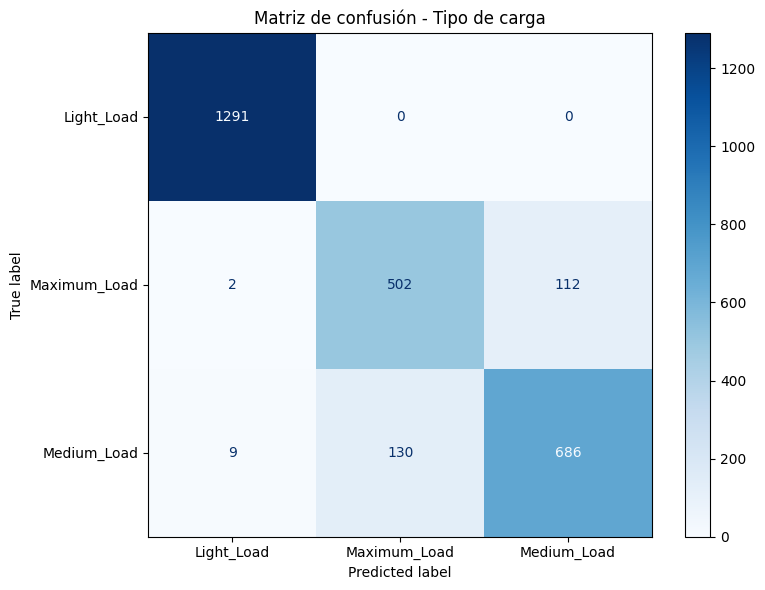

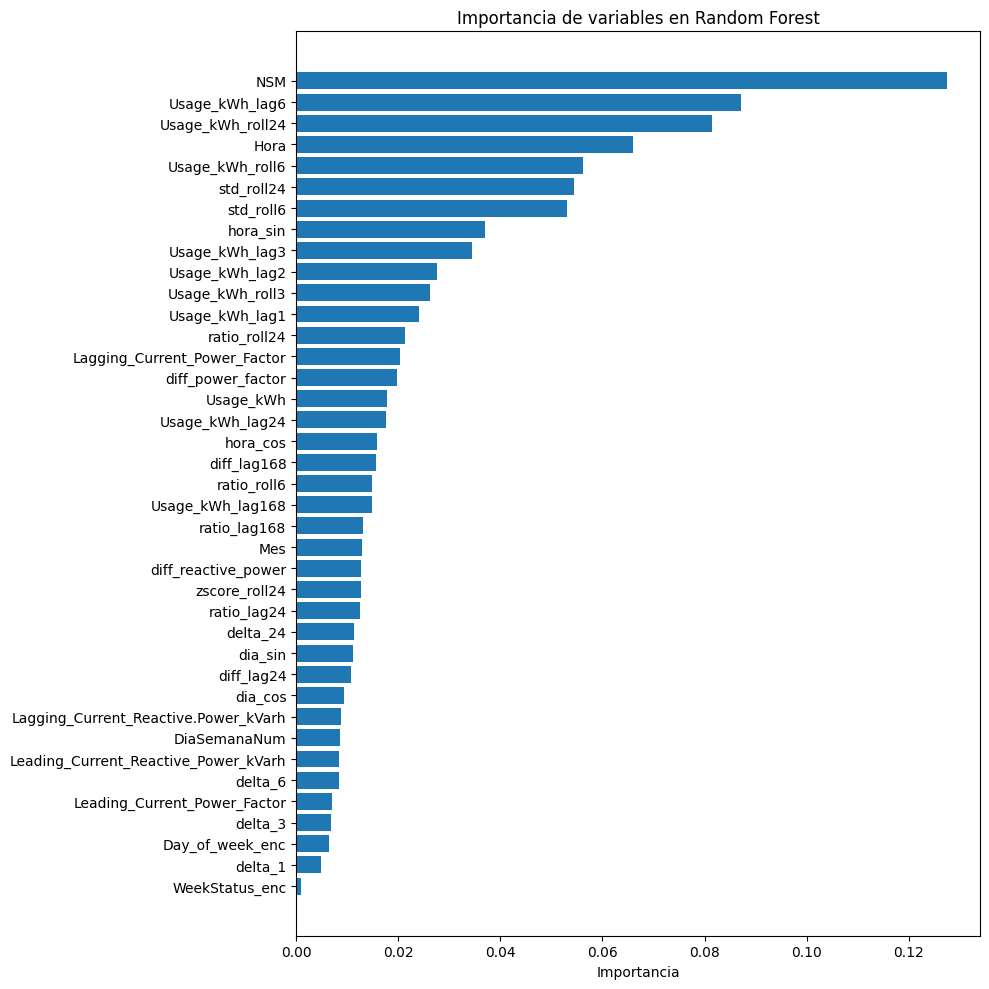


Top 20 variables más importantes:
                        Variable  Importancia
5                            NSM     0.127599
18                Usage_kWh_lag6     0.087155
23              Usage_kWh_roll24     0.081500
8                           Hora     0.066078
22               Usage_kWh_roll6     0.056269
25                    std_roll24     0.054374
24                     std_roll6     0.052992
11                      hora_sin     0.037066
17                Usage_kWh_lag3     0.034369
16                Usage_kWh_lag2     0.027583
21               Usage_kWh_roll3     0.026283
15                Usage_kWh_lag1     0.024030
33                  ratio_roll24     0.021224
3   Lagging_Current_Power_Factor     0.020270
37             diff_power_factor     0.019710
0                      Usage_kWh     0.017860
19               Usage_kWh_lag24     0.017615
12                      hora_cos     0.015801
31                   diff_lag168     0.015631
32                   ratio_roll6     0.014931

In [ ]:
resultados_clasificacion = ejecutar_clasificacion()